In [1]:
# Cấu hình môi trường PyTorch giải phóng bộ nhớ phân mảnh
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# Cài đặt thư viện datasets của Hugging Face phục vụ tải dữ liệu
!pip install -q datasets matplotlib seaborn numpy torch tokenizers nltk pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datasets import load_dataset
import pickle

# Thiết lập seed để đảm bảo kết quả huấn luyện có thể tái lập
torch.manual_seed(42)
np.random.seed(42)

# Cấu hình thiết bị (Ưu tiên GPU CUDA nếu có, ngược lại dùng CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Notebook đang chạy trên thiết bị chính: {device}")

# Kiểm tra số lượng GPU khả dụng để chuẩn bị cấu hình huấn luyện song song
num_gpus = torch.cuda.device_count()
print(f"Số lượng GPU khả dụng: {num_gpus}")


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle
Notebook đang chạy trên thiết bị chính: cuda
Số lượng GPU khả dụng: 2


In [2]:
CKPT_PATH = "/kaggle/input/datasets/vithnguyn7244/mini-transformers/mini_transformer_vi_en.pt"
VOCAB_PATH = "/kaggle/input/datasets/vithnguyn7244/mini-transformers/shared_vocab_recreated.pkl"

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        # Tạo một ma trận PE kích thước [max_len, d_model] chứa toàn số 0
        pe = torch.zeros(max_len, d_model)
        
        # Tạo vector cột chứa các chỉ số vị trí: [max_len, 1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Tính toán mẫu số của công thức: 10000^(2i/d_model)
        # Áp dụng log-space để tính toán nhanh và ổn định hơn về mặt số học
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Điền các giá trị vào ma trận PE:
        # 0::2 chỉ các cột chẵn: tính bằng hàm sin
        pe[:, 0::2] = torch.sin(position * div_term)
        # 1::2 chỉ các cột lẻ: tính bằng hàm cos
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Thêm một chiều ảo ở đầu tiên đại diện cho batch_size: [1, max_len, d_model]
        # Điều này giúp PyTorch tự động phát sóng (broadcast) khi cộng với tensor đầu vào
        pe = pe.unsqueeze(0)
        
        # Đăng ký ma trận pe như một buffer để PyTorch hiểu đây là một tham số tĩnh của mô hình,
        # được lưu trữ cùng state_dict nhưng không được tính gradient hay tối ưu hóa
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        x = x + self.pe[:, :x.size(1)]
        return x


In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model phải chia hết cho num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # Số chiều đặc trưng của mỗi head
        
        # Định nghĩa các lớp chiếu tuyến tính cho Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Lớp chiếu tuyến tính đầu ra sau khi nối các heads
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        # q, k, v shape: [batch_size, seq_len, d_model]
        batch_size = q.size(0)
        
        # Bước 1: Chi chiếu tuyến tính các vector Q, K, V
        # Phép biến hình: [batch_size, seq_len, d_model] -> [batch_size, seq_len, num_heads, d_k] -> [batch_size, num_heads, seq_len, d_k]
        Q = self.W_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # Bước 2: Tính Scaled Dot-Product Attention
        # scores shape: [batch_size, num_heads, seq_len_q, seq_len_k]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # Áp dụng mask (nếu có)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e4)
        
        # Trọng số chú ý: [batch_size, num_heads, seq_len_q, seq_len_k]
        # Áp dụng Attention Dropout theo bài báo gốc
        attn_weights = self.dropout(torch.softmax(scores, dim=-1))
        
        # Nhân với Value: [batch_size, num_heads, seq_len_q, d_k]
        context = torch.matmul(attn_weights, V)
        
        # Bước 3: Nối (Concatenate) các head lại với nhau và chiếu tuyến tính đầu ra
        # context shape: [batch_size, seq_len_q, d_model]
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        # output shape: [batch_size, seq_len_q, d_model]
        output = self.W_o(context)
        
        return output, attn_weights


In [5]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionWiseFeedForward, self).__init__()
        # Lớp tuyến tính thứ nhất (chiếu tăng chiều từ d_model lên d_ff)
        self.w_1 = nn.Linear(d_model, d_ff)
        # Lớp tuyến tính thứ hai (chiếu giảm chiều từ d_ff về lại d_model)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return self.w_2(self.dropout(self.relu(self.w_1(x))))


In [6]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Khối con 1: Self-Attention kết hợp Pre-LN
        norm_x = self.norm1(x)
        attn_out, attn_weights = self.self_attn(norm_x, norm_x, norm_x, mask)
        x = x + self.dropout(attn_out)
        
        # Khối con 2: Feed-Forward kết hợp Pre-LN
        norm_x = self.norm2(x)
        ff_out = self.feed_forward(norm_x)
        x = x + self.dropout(ff_out)
        
        return x, attn_weights


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        # Khối con 1: Masked Self-Attention của Decoder
        norm_x = self.norm1(x)
        self_attn_out, self_attn_weights = self.self_attn(norm_x, norm_x, norm_x, tgt_mask)
        x = x + self.dropout(self_attn_out)
        
        # Khối con 2: Cross-Attention kết nối Decoder và Encoder
        # Query lấy từ Decoder (norm_x), Key và Value lấy từ Encoder (enc_output)
        norm_x = self.norm2(x)
        cross_attn_out, cross_attn_weights = self.cross_attn(norm_x, enc_output, enc_output, src_mask)
        x = x + self.dropout(cross_attn_out)
        
        # Khối con 3: Feed-Forward Network
        norm_x = self.norm3(x)
        ff_out = self.feed_forward(norm_x)
        x = x + self.dropout(ff_out)
        
        return x, self_attn_weights, cross_attn_weights


In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=5000, dropout=0.1, embedding=None):
        super(Encoder, self).__init__()
        self.d_model = d_model
        if embedding is not None:
            self.embedding = embedding
        else:
            self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, mask=None):
        # Nhân scale sqrt(d_model) theo bài báo gốc trước khi cộng PE
        x = self.embedding(src) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        attn_list = []
        for layer in self.layers:
            x, attn_weights = layer(x, mask)
            attn_list.append(attn_weights)
        return self.norm(x), attn_list


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=5000, dropout=0.1, embedding=None):
        super(Decoder, self).__init__()
        self.d_model = d_model
        if embedding is not None:
            self.embedding = embedding
        else:
            self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, enc_output, src_mask=None, tgt_mask=None):
        # Nhân scale sqrt(d_model) theo bài báo gốc trước khi cộng PE
        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        self_attn_list = []
        cross_attn_list = []
        for layer in self.layers:
            x, self_attn, cross_attn = layer(x, enc_output, src_mask, tgt_mask)
            self_attn_list.append(self_attn)
            cross_attn_list.append(cross_attn)
        return self.norm(x), self_attn_list, cross_attn_list


class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6, num_heads=8, d_ff=2048, max_len=5000, dropout=0.1):
        super(Transformer, self).__init__()
        self.num_layers = num_layers
        
        # Nếu kích thước từ điển nguồn và đích bằng nhau, ta dùng Shared Embedding
        if src_vocab_size == tgt_vocab_size:
            self.shared_embedding = nn.Embedding(src_vocab_size, d_model)
            self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout, embedding=self.shared_embedding)
            self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout, embedding=self.shared_embedding)
            self.generator = nn.Linear(d_model, tgt_vocab_size, bias=False)
            self.generator.weight = self.shared_embedding.weight
        else:
            self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
            self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
            self.generator = nn.Linear(d_model, tgt_vocab_size, bias=False)
            self.generator.weight = self.decoder.embedding.weight
        
        # Áp dụng khởi tạo trọng số tùy chỉnh trước
        self.apply(self._init_weights)
        
        # Đồng bộ lại Tied Weights sau khởi tạo
        if src_vocab_size == tgt_vocab_size:
            self.generator.weight = self.shared_embedding.weight
        else:
            self.generator.weight = self.decoder.embedding.weight

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)
        
        # Khởi tạo trọng số có tỉ lệ (Scaled Initialization cho Pre-LN projection layers)
        if isinstance(module, EncoderLayer) or isinstance(module, DecoderLayer):
            if hasattr(module, 'self_attn') and hasattr(module.self_attn, 'W_o'):
                nn.init.normal_(module.self_attn.W_o.weight, mean=0.0, std=0.02 / math.sqrt(2 * self.num_layers))
            if hasattr(module, 'cross_attn') and hasattr(module.cross_attn, 'W_o'):
                nn.init.normal_(module.cross_attn.W_o.weight, mean=0.0, std=0.02 / math.sqrt(2 * self.num_layers))
            if hasattr(module, 'feed_forward') and hasattr(module.feed_forward, 'w_2'):
                nn.init.normal_(module.feed_forward.w_2.weight, mean=0.0, std=0.02 / math.sqrt(2 * self.num_layers))

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        enc_output, enc_attn = self.encoder(src, src_mask)
        dec_output, dec_self_attn, dec_cross_attn = self.decoder(tgt, enc_output, src_mask, tgt_mask)
        logits = self.generator(dec_output)
        return logits, enc_attn, dec_self_attn, dec_cross_attn


In [8]:
import html
from tokenizers import Tokenizer, normalizers
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import NFKC, Lowercase

def clean_text(text):
    text = html.unescape(text)  # Giải mã thực thể HTML: &apos; -> ', &quot; -> "
    text = text.strip().lower()
    # Giữ lại các dấu câu cơ bản để hỗ trợ dịch chính xác hơn, chỉ chuẩn hóa unicode và dấu ngoặc
    text = re.sub(r"[“”“«»]", "\"", text)
    text = re.sub(r"[‘’`´]", "'", text)
    text = re.sub(r"[–—]", "-", text)
    return text

class BPETokenizer:
    def __init__(self, vocab_size=18000):
        self.vocab_size = vocab_size
        self.tokenizer = Tokenizer(BPE(unk_token="<unk>"))
        # Sử dụng NFKC Normalizer tích hợp của Hugging Face để chuẩn hóa ký tự tiếng Việt
        self.tokenizer.normalizer = normalizers.Sequence([NFKC(), Lowercase()])
        self.tokenizer.pre_tokenizer = Whitespace()
        self.trainer = BpeTrainer(
            special_tokens=["<pad>", "<sos>", "<eos>", "<unk>"],
            vocab_size=self.vocab_size
        )

    def train(self, sentences):
        cleaned = [clean_text(s) for s in sentences]
        self.tokenizer.train_from_iterator(cleaned, self.trainer)

    def encode(self, sentence, add_special=True):
        cleaned = clean_text(sentence)
        ids = self.tokenizer.encode(cleaned).ids
        if add_special:
            ids = [1] + ids + [2]  # <sos>=1, <eos>=2
        return ids

    def decode(self, ids):
        filtered = [idx for idx in ids if idx not in [0, 1, 2]]
        return self.tokenizer.decode(filtered)

    @property
    def word2idx(self):
        return {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}

    @property
    def idx2word(self):
        class _IdToToken:
            def __init__(self, tok):
                self.tok = tok
            def __getitem__(self, idx):
                val = self.tok.id_to_token(idx)
                return val if val is not None else "<unk>"
            def get(self, idx, default="<unk>"):
                val = self.tok.id_to_token(idx)
                return val if val is not None else default
        return _IdToToken(self.tokenizer)

    def __len__(self):
        return self.tokenizer.get_vocab_size()


In [9]:
class TranslationDataset(Dataset):
    def __init__(self, raw_data, max_len=None):
        self.pairs = []
        for item in raw_data:
            src = item['vi']
            tgt = item['en']
            if max_len is not None:
                if len(src.split()) > max_len or len(tgt.split()) > max_len:
                    continue
            self.pairs.append((src, tgt))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

class BucketBatchSampler(torch.utils.data.Sampler):
    def __init__(self, dataset, batch_size, shuffle=True):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = list(range(len(dataset)))
        # Sắp xếp các câu theo chiều dài của câu nguồn (tiếng Việt)
        self.indices.sort(key=lambda idx: len(dataset.pairs[idx][0].split()))
        
    def __iter__(self):
        # Tạo các batches từ danh sách đã sắp xếp để giảm thiểu padding
        batches = [self.indices[i:i + self.batch_size] for i in range(0, len(self.indices), self.batch_size)]
        if self.shuffle:
            np.random.shuffle(batches)
        for batch in batches:
            yield batch
            
    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

def get_collate_fn(src_vocab, tgt_vocab):
    def collate_fn(batch):
        src_batch, tgt_batch = [], []
        for src_sent, tgt_sent in batch:
            src_batch.append(src_vocab.encode(src_sent, add_special=False))
            tgt_batch.append(tgt_vocab.encode(tgt_sent, add_special=True))
        
        max_src_len = max(len(s) for s in src_batch)
        max_tgt_len = max(len(t) for t in tgt_batch)
        
        padded_src = [s + [0] * (max_src_len - len(s)) for s in src_batch]
        padded_tgt = [t + [0] * (max_tgt_len - len(t)) for t in tgt_batch]
        
        return torch.tensor(padded_src, dtype=torch.long), torch.tensor(padded_tgt, dtype=torch.long)
    return collate_fn


In [10]:
with open(VOCAB_PATH, "rb") as f:
    shared_vocab = pickle.load(f)

src_vocab = shared_vocab
tgt_vocab = shared_vocab

print("Vocab size:", len(shared_vocab))

Vocab size: 18000


In [11]:
state_dict = torch.load(CKPT_PATH, map_location="cpu")

print("Number of keys:", len(state_dict))

vocab_size = state_dict["encoder.embedding.weight"].shape[0]
d_model = state_dict["encoder.embedding.weight"].shape[1]

print("Checkpoint vocab_size:", vocab_size)
print("Checkpoint d_model:", d_model)
print("Loaded vocab size:", len(shared_vocab))

Number of keys: 262
Checkpoint vocab_size: 18000
Checkpoint d_model: 512
Loaded vocab size: 18000


In [12]:
model = Transformer(
    src_vocab_size=vocab_size,
    tgt_vocab_size=vocab_size,
    d_model=512,
    num_layers=6,
    num_heads=8,
    d_ff=2048,
    max_len=5000,
    dropout=0.1
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


# TRÍCH XUẤT ma trận trọng số đã train thành công

In [13]:
attn = model.encoder.layers[0].self_attn

W_q = attn.W_q.weight
W_k = attn.W_k.weight
W_v = attn.W_v.weight

print("W_q:", W_q.shape)
print("W_k:", W_k.shape)
print("W_v:", W_v.shape)

W_q: torch.Size([512, 512])
W_k: torch.Size([512, 512])
W_v: torch.Size([512, 512])


In [14]:
src_sentence = "tôi muốn học transformer"
try:
    src_ids = src_vocab.encode(src_sentence, add_special=False)
except TypeError:
    src_ids = src_vocab.encode(src_sentence)

print("src_ids:", src_ids)

src_ids: [196, 510, 440, 3560, 181]


In [15]:
def ids_to_tokens(vocab, ids):
    tokens = []
    for idx in ids:
        if hasattr(vocab, "idx2word"):
            tokens.append(vocab.idx2word[idx])
        elif hasattr(vocab, "idx_to_token"):
            tokens.append(vocab.idx_to_token[idx])
        elif hasattr(vocab, "id_to_token"):
            tokens.append(vocab.id_to_token[idx])
        elif hasattr(vocab, "itos"):
            tokens.append(vocab.itos[idx])
        else:
            tokens.append(f"id_{idx}")
    return tokens

src_tokens = ids_to_tokens(src_vocab, src_ids)

print("src_tokens:", src_tokens)

src_tokens: ['tôi', 'muốn', 'học', 'transform', 'er']


In [16]:
src = torch.tensor([src_ids], dtype=torch.long).to(device)
print("src shape:", src.shape)

src shape: torch.Size([1, 5])


# Chạy thủ công bước đầu của encoder: embedding → positional encoding → layer norm trước attention.

In [17]:
model.eval()

with torch.no_grad():
    layer0 = model.encoder.layers[0]
    attn = layer0.self_attn

    x = model.encoder.embedding(src) * math.sqrt(model.encoder.d_model)
    x = model.encoder.pos_encoding(x)
    x = model.encoder.dropout(x)

    norm_x = layer0.norm1(x)

print("x shape:", x.shape)
print("norm_x shape:", norm_x.shape)

x shape: torch.Size([1, 5, 512])
norm_x shape: torch.Size([1, 5, 512])


# Tính Q_linear, K_linear, V_linear bằng cách đưa vector token qua các ma trận W_q, W_k, W_v.

In [18]:
with torch.no_grad():
    Q_linear = attn.W_q(norm_x)
    K_linear = attn.W_k(norm_x)
    V_linear = attn.W_v(norm_x)

print("Q_linear:", Q_linear.shape)
print("K_linear:", K_linear.shape)
print("V_linear:", V_linear.shape)

Q_linear: torch.Size([1, 5, 512])
K_linear: torch.Size([1, 5, 512])
V_linear: torch.Size([1, 5, 512])


# Reshape Q, K, V thành dạng multi-head: [batch, num_heads, seq_len, d_k].

In [19]:
batch_size = src.size(0)
seq_len = src.size(1)
num_heads = attn.num_heads
d_k = attn.d_k

with torch.no_grad():
    Q = Q_linear.view(batch_size, seq_len, num_heads, d_k).transpose(1, 2)
    K = K_linear.view(batch_size, seq_len, num_heads, d_k).transpose(1, 2)
    V = V_linear.view(batch_size, seq_len, num_heads, d_k).transpose(1, 2)

print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)

Q: torch.Size([1, 8, 5, 64])
K: torch.Size([1, 8, 5, 64])
V: torch.Size([1, 8, 5, 64])


# Tính attention thủ công: QK^T, chia sqrt(d_k), softmax ra attention weights, rồi nhân với V để ra context.

In [20]:
with torch.no_grad():
    raw_scores = torch.matmul(Q, K.transpose(-2, -1))
    scaled_scores = raw_scores / math.sqrt(d_k)

    # Nếu câu không có padding, có thể bỏ mask.
    attention_weights = torch.softmax(scaled_scores, dim=-1)
    context = torch.matmul(attention_weights, V)

print("raw_scores:", raw_scores.shape)
print("scaled_scores:", scaled_scores.shape)
print("attention_weights:", attention_weights.shape)
print("context:", context.shape)

raw_scores: torch.Size([1, 8, 5, 5])
scaled_scores: torch.Size([1, 8, 5, 5])
attention_weights: torch.Size([1, 8, 5, 5])
context: torch.Size([1, 8, 5, 64])


# Vẽ heatmap attention của head 0 để trực quan hóa token nào đang chú ý tới token nào.

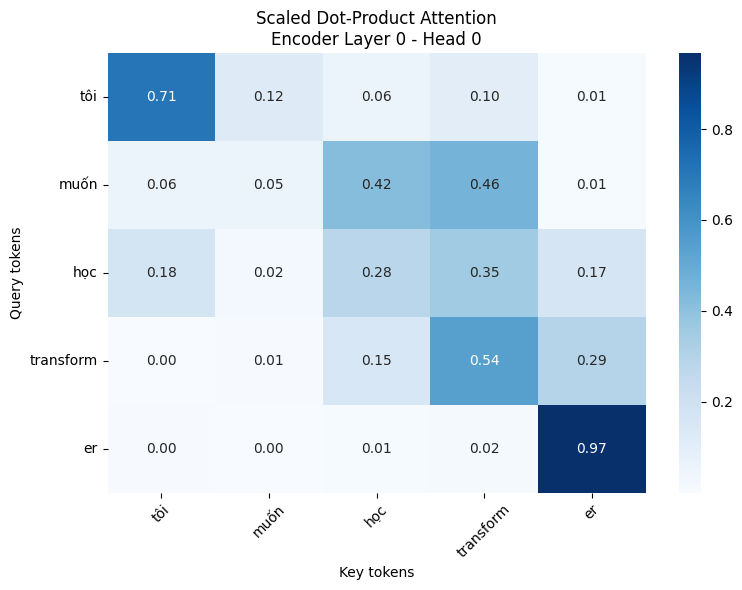

In [21]:
head_id = 0

attn_map = attention_weights[0, head_id].detach().cpu().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(
    attn_map,
    xticklabels=src_tokens,
    yticklabels=src_tokens,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    cbar=True
)

plt.title(f"Scaled Dot-Product Attention\nEncoder Layer 0 - Head {head_id}")
plt.xlabel("Key tokens")
plt.ylabel("Query tokens")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()